In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV

from scikeras.wrappers import KerasClassifier

In [ ]:
os.makedirs("plots", exist_ok=True)

plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["savefig.dpi"] = 600

def save_plot(name):
    """Save the current figure as a 600 dpi PNG inside plots/ and display it."""
    plt.tight_layout()
    plt.savefig(f"plots/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

## Task 1: Dataset Exploration

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)

print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Image size:", X_train.shape[1], "x", X_train.shape[2])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)
Number of classes: 10
Image size: 28 x 28


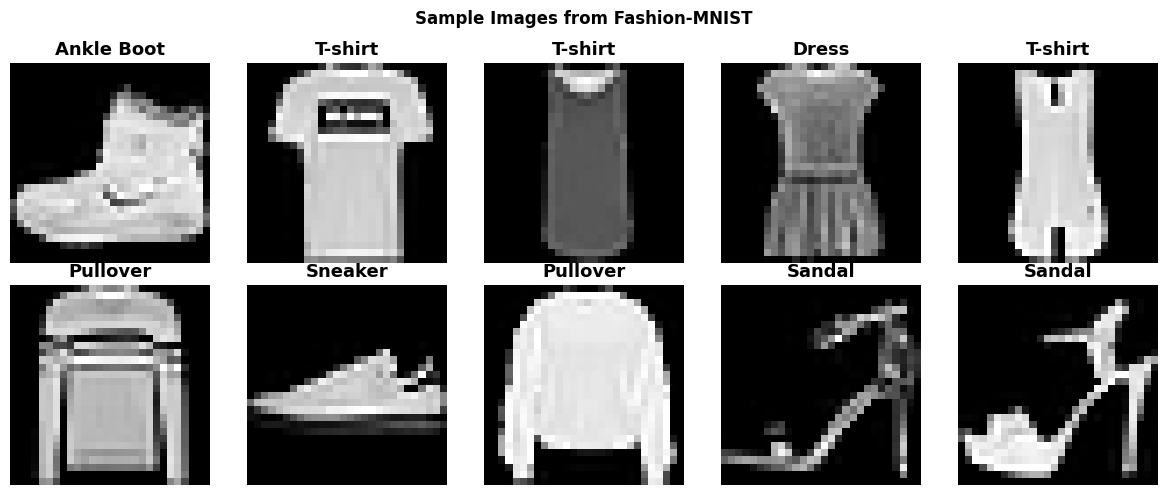

In [ ]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontweight='bold')
    plt.axis('off')

plt.suptitle("Sample Images from Fashion-MNIST", fontweight='bold')
save_plot("01_sample_images")

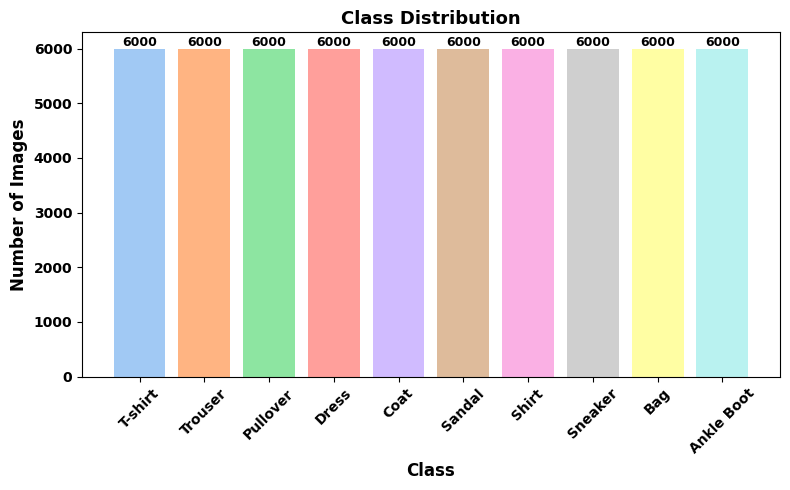

In [ ]:
counts = np.bincount(y_train)

plt.figure(figsize=(8,5))
plt.bar(range(10), counts, color=sns.color_palette('pastel'))

for i, c in enumerate(counts):
    plt.text(i, c + 50, str(c), ha='center', fontweight='bold', fontsize=9)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(range(10), class_names, rotation=45)
save_plot("02_class_distribution")

## Task 2: Data Preprocessing

In [ ]:
print("Before Flattening:", X_train.shape, X_test.shape)

X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print("After Flattening:", X_train.shape, X_test.shape)

print("Pixel range before normalization:", X_train.min(), "-", X_train.max())

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Pixel range after normalization:", X_train.min(), "-", X_train.max())

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Labels before one-hot:", y_train.shape)
print("Labels after one-hot:", y_train_cat.shape)

Before Flattening: (60000, 28, 28) (10000, 28, 28)
After Flattening: (60000, 784) (10000, 784)
Pixel range before normalization: 0 - 255
Pixel range after normalization: 0.0 - 1.0
Labels before one-hot: (60000,)
Labels after one-hot: (60000, 10)


## Task 3: Model Construction

In [ ]:
baseline = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Model Training

In [ ]:
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history = baseline.fit(X_train, y_train_cat, epochs=20, batch_size=32, validation_split=0.2, verbose=1)
baseline_time = time.time() - start

print("Baseline training time (seconds):", round(baseline_time, 2))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8153 - loss: 0.5179 - val_accuracy: 0.8539 - val_loss: 0.4017
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8606 - loss: 0.3829 - val_accuracy: 0.8651 - val_loss: 0.3761
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8724 - loss: 0.3435 - val_accuracy: 0.8691 - val_loss: 0.3670
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8833 - loss: 0.3189 - val_accuracy: 0.8784 - val_loss: 0.3387
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8894 - loss: 0.2983 - val_accuracy: 0.8818 - val_loss: 0.3260
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8951 - loss: 0.2852 - val_accuracy: 0.8751 - val_loss: 0.3422
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8967 - loss: 0.2734 - val_accuracy: 0.8813 - val_loss: 0.3418
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9040 - loss: 0.2609 -

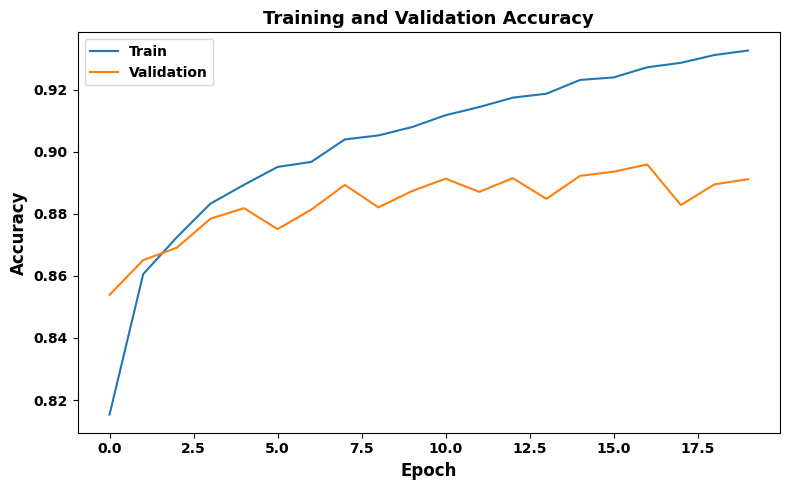

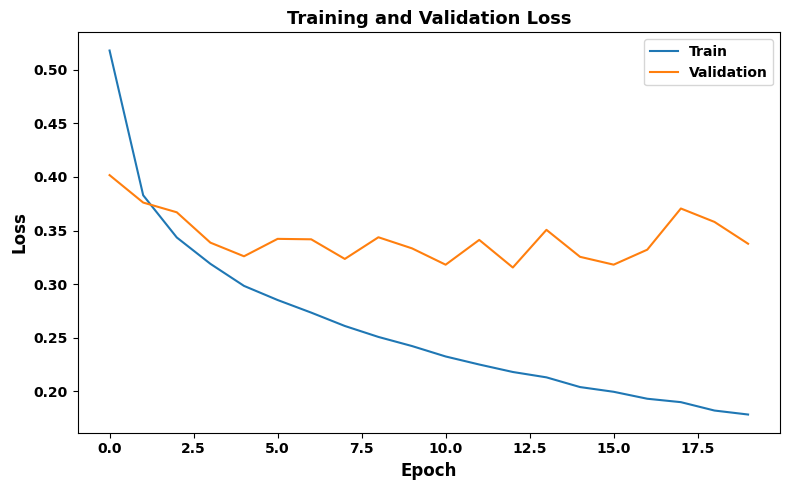

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
save_plot("03_04_accuracy_baseline")
print()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_plot("05_06_loss_baseline")

## Task 5: Model Evaluation (Baseline)

In [ ]:
pred = baseline.predict(X_test)
pred_classes = np.argmax(pred, axis=1)

baseline_acc = accuracy_score(y_test, pred_classes)
baseline_prec = precision_score(y_test, pred_classes, average='weighted')
baseline_rec = recall_score(y_test, pred_classes, average='weighted')
baseline_f1 = f1_score(y_test, pred_classes, average='weighted')

print("Accuracy:", baseline_acc)
print("Precision:", baseline_prec)
print("Recall:", baseline_rec)
print("F1:", baseline_f1)
print("Classification Report:\n", classification_report(y_test, pred_classes, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step
Accuracy: 0.8831
Precision: 0.8835381364618284
Recall: 0.8831
F1: 0.881754754290688
Classification Report:
               precision    recall  f1-score   support

     T-shirt       0.77      0.90      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.79      0.79      1000
       Dress       0.89      0.90      0.89      1000
        Coat       0.78      0.82      0.80      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.77      0.61      0.68      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### Plot 7: Confusion Matrix (Baseline)

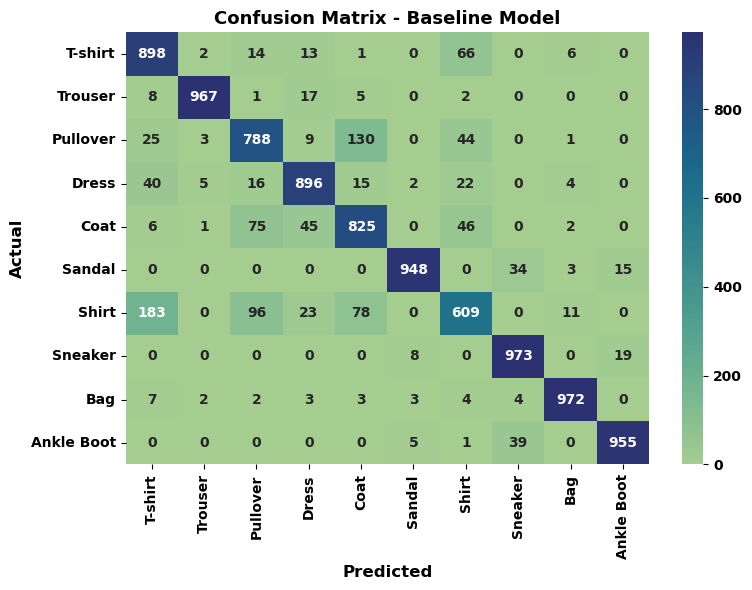

In [ ]:
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
save_plot("07_confusion_matrix_baseline")

## Hyperparameter Optimization

In [ ]:
def build_model(hidden_layers=2,
                neurons=128,
                activation="relu",
                optimizer="adam",
                learning_rate=0.001,
                dropout=0.0):

    model = Sequential()

    model.add(Input(shape=(784,)))

    model.add(Dense(neurons, activation=activation))
    model.add(Dropout(dropout))

    for _ in range(hidden_layers-1):
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(dropout))

    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)

    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
clf = KerasClassifier(
    model=build_model,
    hidden_layers=2,
    neurons=128,
    activation="relu",
    optimizer="adam",
    learning_rate=0.001,
    dropout=0.0,
    verbose=0
)

In [ ]:
param_grid = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
    "model__optimizer": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout": [0.0, 0.2, 0.5]
}

In [ ]:
SEARCH_SIZE = 60000

rng = np.random.RandomState(42)
idx = rng.choice(len(X_train), SEARCH_SIZE, replace=False)
X_search, y_search = X_train[idx], y_train[idx]

print("Search subset:", X_search.shape, y_search.shape)

Search subset: (60000, 784) (60000,)


In [ ]:
search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=True,
    error_score="raise"
)

search.fit(X_search, y_search)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time=  26.3s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time=  26.5s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time=  24.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer=adam; total time=  25.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer

RandomizedSearchCV(cv=5, error_score='raise',
                   estimator=KerasClassifier(activation='relu', dropout=0.0, hidden_layers=2, learning_rate=0.001, model=<function build_model at 0x34f047ec0>, neurons=128, optimizer='adam', verbose=0),
                   n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__neurons': [32, 64, 128, 256],
                                        'model__optimizer': ['sgd', 'adam',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
print("Best hyperparameters:")
for parameter, value in search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nCross-validation accuracy:", search.best_score_)

Best hyperparameters:
model__optimizer: adam
model__neurons: 256
model__learning_rate: 0.001
model__hidden_layers: 2
model__dropout: 0.0
model__activation: sigmoid
epochs: 30
batch_size: 32

Cross-validation accuracy: 0.8965833333333334


### Plot 8: Hyperparameter Search Results

In [ ]:
results = pd.DataFrame(search.cv_results_)
cols = [c for c in results.columns if c.startswith("param_")] + ["mean_test_score", "std_test_score", "rank_test_score"]
results = results[cols].sort_values("mean_test_score", ascending=False)

print(results.to_string())

  param_model__optimizer  param_model__neurons  param_model__learning_rate  param_model__hidden_layers  param_model__dropout param_model__activation  param_epochs  param_batch_size  mean_test_score  std_test_score  rank_test_score
9                   adam                   256                       0.001                           2                   0.0                 sigmoid            30                32         0.896583        0.003504                1
0                   adam                   256                       0.001                           1                   0.2                    tanh            20                64         0.891617        0.002147                2
8                   adam                   256                       0.001                           3                   0.2                    tanh            20                32         0.880533        0.002026                3
7                   adam                   256                       0.001  

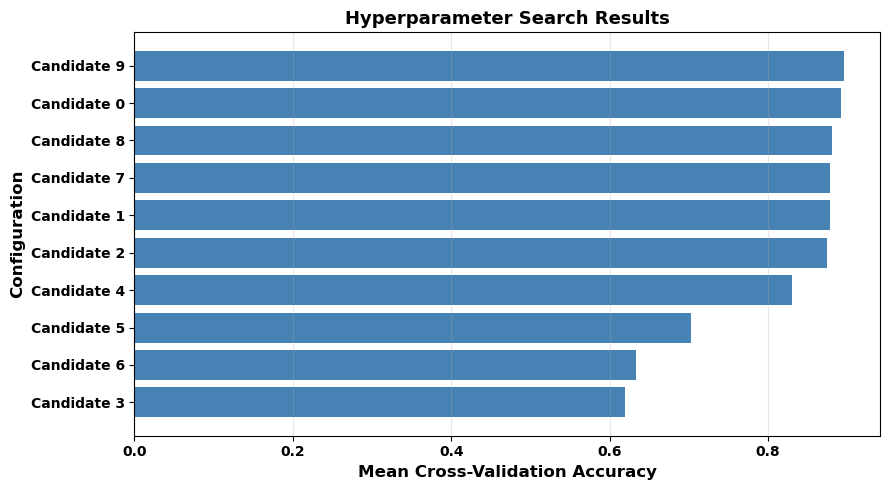

In [ ]:
plt.figure(figsize=(9,5))
plt.barh([f"Candidate {i}" for i in results.index], results["mean_test_score"], color='steelblue')
plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Configuration")
plt.title("Hyperparameter Search Results")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
save_plot("08_hyperparameter_search_results")

In [ ]:
bp = search.best_params_

opt_model = build_model(
    hidden_layers=bp["model__hidden_layers"],
    neurons=bp["model__neurons"],
    activation=bp["model__activation"],
    optimizer=bp["model__optimizer"],
    learning_rate=bp["model__learning_rate"],
    dropout=bp["model__dropout"]
)

opt_model.summary()

start = time.time()
history_opt = opt_model.fit(X_train, y_train,
                            epochs=bp["epochs"],
                            batch_size=bp["batch_size"],
                            validation_split=0.2,
                            verbose=1)
opt_time = time.time() - start

print("Optimized training time (seconds):", round(opt_time, 2))

Model: "sequential_104"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_292 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_186 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_293 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_187 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_294 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7194 - loss: 0.8036 - val_accuracy: 0.8459 - val_loss: 0.4191
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8563 - loss: 0.3963 - val_accuracy: 0.8505 - val_loss: 0.3972
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8674 - loss: 0.3618 - val_accuracy: 0.8683 - val_loss: 0.3556
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8814 - loss: 0.3268 - val_accuracy: 0.8722 - val_loss: 0.3473
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8871 - loss: 0.3034 - val_accuracy: 0.8759 - val_loss: 0.3316
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8905 - loss: 0.2914 - val_accuracy: 0.8827 - val_loss: 0.3272
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8981 - loss: 0.2664 - val_accuracy: 0.8840 - val_loss: 0.3216
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9017 - loss: 0.2619 - 

### Training and Validation Accuracy / Loss (Optimized)

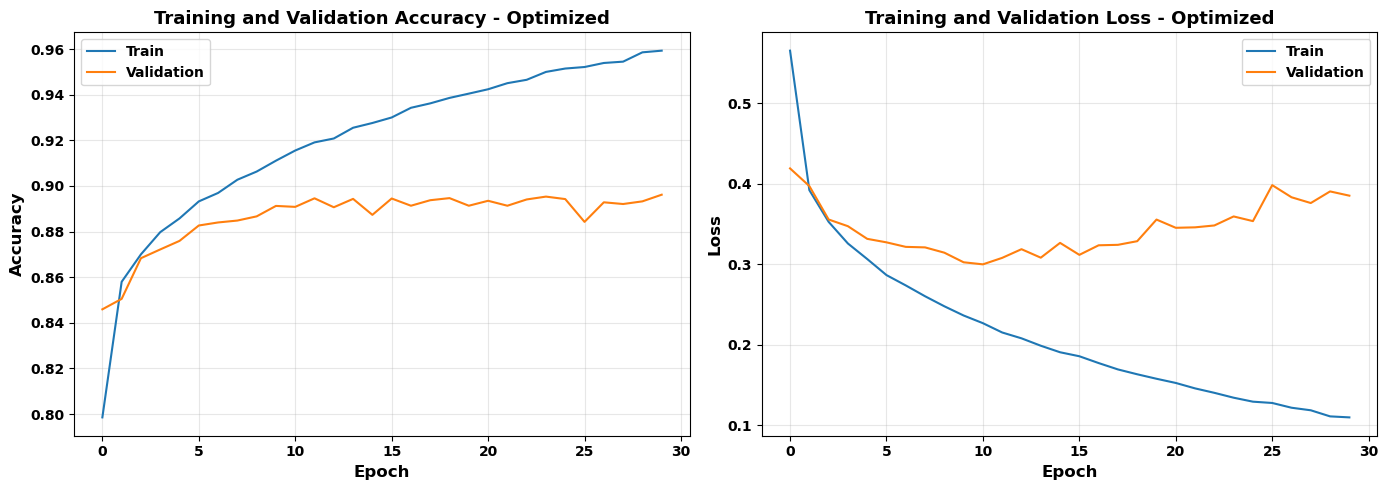

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_opt.history['accuracy'], label='Train')
axes[0].plot(history_opt.history['val_accuracy'], label='Validation')
axes[0].set_title("Training and Validation Accuracy - Optimized")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_opt.history['loss'], label='Train')
axes[1].plot(history_opt.history['val_loss'], label='Validation')
axes[1].set_title("Training and Validation Loss - Optimized")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

save_plot("03_06_accuracy_loss_optimized")

### Evaluate the optimized model

In [ ]:
y_pred_opt = np.argmax(opt_model.predict(X_test), axis=1)

opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt, average='weighted')
opt_rec = recall_score(y_test, y_pred_opt, average='weighted')
opt_f1 = f1_score(y_test, y_pred_opt, average='weighted')

print("Accuracy:", opt_acc)
print("Precision:", opt_prec)
print("Recall:", opt_rec)
print("F1:", opt_f1)
print("Classification Report:\n", classification_report(y_test, y_pred_opt, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step
Accuracy: 0.893
Precision: 0.8926824253338999
Recall: 0.893
F1: 0.8924495493662489
Classification Report:
               precision    recall  f1-score   support

     T-shirt       0.85      0.84      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.83      0.82      1000
       Dress       0.85      0.94      0.89      1000
        Coat       0.84      0.78      0.81      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.74      0.70      0.72      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



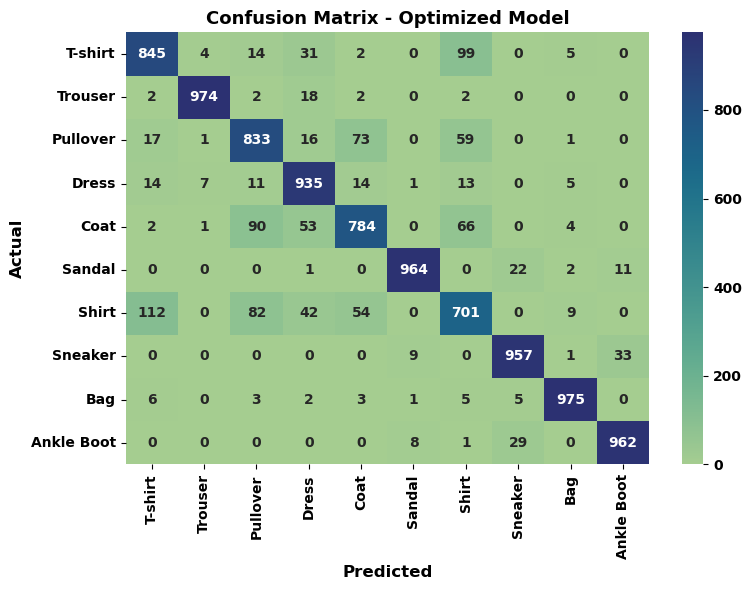

In [ ]:
cm_opt = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(8,6))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='crest', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Optimized Model")
save_plot("07b_confusion_matrix_optimized")

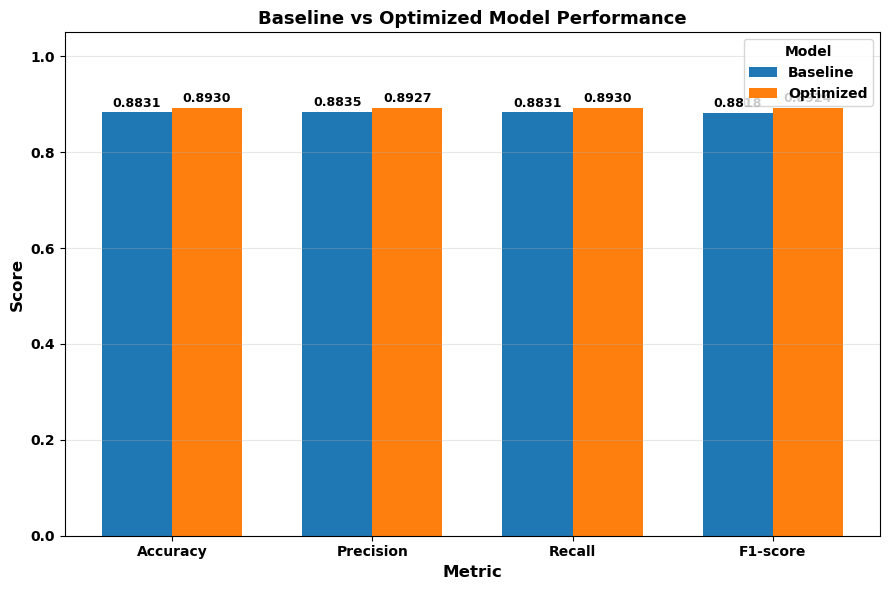

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_scores = [opt_acc, opt_prec, opt_rec, opt_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,6))
b1 = plt.bar(x - width/2, baseline_scores, width, label="Baseline")
b2 = plt.bar(x + width/2, optimized_scores, width, label="Optimized")

for bars in (b1, b2):
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f"{bar.get_height():.4f}", ha='center', fontweight='bold', fontsize=9)

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Baseline vs Optimized Model Performance")
plt.legend(title="Model")
plt.grid(axis='y', alpha=0.3)
save_plot("09_baseline_vs_optimized_metrics")

### Performance Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"],
    "Baseline": [baseline_acc, baseline_prec, baseline_rec, baseline_f1, round(baseline_time, 2)],
    "Optimized": [opt_acc, opt_prec, opt_rec, opt_f1, round(opt_time, 2)]
})

print(comparison.to_string(index=False))
comparison.to_csv("plots/performance_comparison.csv", index=False)

           Metric  Baseline  Optimized
         Accuracy  0.883100   0.893000
        Precision  0.883538   0.892682
           Recall  0.883100   0.893000
         F1-score  0.881755   0.892450
Training Time (s) 37.560000 106.020000


Code the perceptron learning algorithm for the XOR gate using Python. Show the weights after each update. Plot the decision boundary after each weight update using Python's built-in packages. Analyze and identify the pattern that prevents the algorithm from converging.

In [ ]:
def step(x):
    return 1 if x >= 0 else 0

def plot_all_updates(X, y, snapshots, title, ncols=4):
    n = len(snapshots)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows), squeeze=False)
    two_inputs = X.shape[1] == 2

    for k, ax in enumerate(axes.flatten()):
        if k >= n:
            ax.axis("off")
            continue
        w, b, label = snapshots[k]

        for i in range(len(X)):
            colour = "red" if y[i] == 0 else "blue"
            ax.scatter(X[i][0], X[i][1] if two_inputs else 0,
                       color=colour, s=80, zorder=3)

        if two_inputs and abs(w[1]) > 1e-6:
            x_line = np.linspace(-0.5, 1.5, 100)
            ax.plot(x_line, -(w[0] * x_line + b) / w[1], 'k-')
        elif abs(w[0]) > 1e-6:
            ax.axvline(x=-b / w[0], color='black')

        ax.set_xlim(-0.5, 1.5)
        if two_inputs:
            ax.set_ylim(-0.5, 1.5)
            ax.set_yticks([0, 1])
        else:
            ax.set_ylim(-0.5, 0.5)
            ax.set_yticks([])
        ax.set_xticks([0, 1])
        ax.grid(True)
        ax.set_title(f"{label}\nw={np.round(w, 2)}, b={b}", fontsize=9)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def perceptron_learning(X, y, lr=0.05, epochs=3, title="Gate"):
    w = np.zeros(X.shape[1])
    b = 0
    update = 1
    snapshots = []

    for epoch in range(epochs):
        error_count = 0
        for i in range(len(X)):
            output = step(np.dot(X[i], w) + b)
            error = y[i] - output
            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error

                print(f"Update {update}: input {tuple(int(v) for v in X[i])}, "
                      f"error {int(error):+d}  ->  weights {w}, bias {b}")

                snapshots.append((w.copy(), b, f"Update {update}"))
                update += 1
                error_count += 1

        if error_count == 0:
            break

    print("Final Weights:", w)
    print("Final Bias:", b)
    print("Predictions:", [step(np.dot(x, w) + b) for x in X])

    plot_all_updates(X, y, snapshots, title)
    return w, b

Update 1: input (0, 0), error -1  ->  weights [0. 0.], bias -0.05
Update 2: input (0, 1), error +1  ->  weights [0.   0.05], bias 0.0
Update 3: input (1, 1), error -1  ->  weights [-0.05  0.  ], bias -0.05
Update 4: input (0, 1), error +1  ->  weights [-0.05  0.05], bias 0.0
Update 5: input (1, 0), error +1  ->  weights [0.   0.05], bias 0.05
Update 6: input (1, 1), error -1  ->  weights [-0.05  0.  ], bias 0.0
Update 7: input (0, 0), error -1  ->  weights [-0.05  0.  ], bias -0.05
Update 8: input (0, 1), error +1  ->  weights [-0.05  0.05], bias 0.0
Update 9: input (1, 0), error +1  ->  weights [0.   0.05], bias 0.05
Update 10: input (1, 1), error -1  ->  weights [-0.05  0.  ], bias 0.0
Final Weights: [-0.05  0.  ]
Final Bias: 0.0
Predictions: [1, 1, 0, 0]


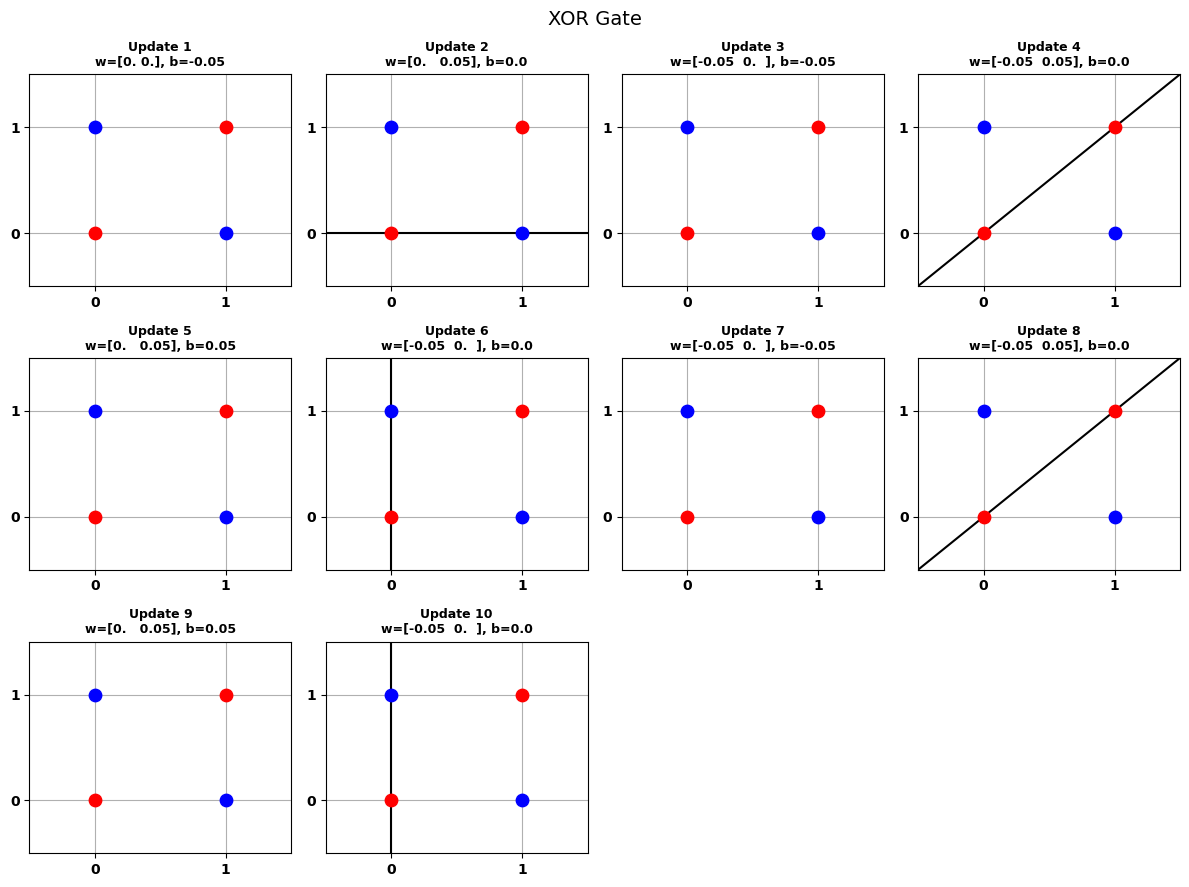

(array([-0.05,  0.  ]), np.float64(0.0))

In [ ]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0,1,1,0])
perceptron_learning(X_xor, y_xor, title = "XOR Gate")